
Name: Shahzaib Mahar

CMD ID: 023-24-0282

Section: H

Github: https://github.com/smaharx/Code




In [24]:
#Task 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Define the path to the cleaned dataset
cleaned_data_filename = '/content/clean_churn.csv'

# Load the cleaned dataset
print(f"Loading '{cleaned_data_filename}'...")
df_churn = pd.read_csv(cleaned_data_filename)
print("Data loaded successfully into `df_churn`.")

# Verify its shape
print("\n--- Dataset Shape ---")
print(df_churn.shape)

# Verify column dtypes
print("\n--- Column Data Types ---")
# Using .info() for a concise summary including non-null counts and dtypes
df_churn.info()

# Verify no missing values remaining
print("\n--- Missing Values Check ---")
missing_values_series = df_churn.isnull().sum()
missing_values_count = missing_values_series.sum()
if missing_values_count == 0:
    print("No missing values found in the dataset.")
else:
    print(f"WARNING: {missing_values_count} missing values found across the following columns:\n{missing_values_series[missing_values_series > 0]}")


Loading '/content/clean_churn.csv'...
Data loaded successfully into `df_churn`.

--- Dataset Shape ---
(7043, 20)

--- Column Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 


Task 2:

**In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the
business?**

**Answer**:


3. Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any
identifier column still present.
4. Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding
method (e.g. one-hot vs. manual mapping).
5. Confirm X contains only numeric columns and has no missing values before moving on.

In [25]:
#Task 3
y = df_churn["Churn"].map({"Yes": 1, "No": 0})
x = df_churn.drop("Churn", axis=1)
#printing
x
y


,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [26]:
#Task 4
categorical_cols = x.select_dtypes(include=["object"]).columns.tolist()
#printing
categorical_cols

x_encoded = pd.get_dummies(x,columns = categorical_cols)
#printing
x_encoded

,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,True,False,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,34,56.95,1889.50,False,True,True,False,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,2,53.85,108.15,False,True,True,False,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,45,42.30,1840.75,False,True,True,False,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,2,70.70,151.65,True,False,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,24,84.80,1990.50,False,True,True,False,False,True,False,...,True,False,True,False,False,True,False,False,False,True
7039,72,103.20,7362.90,True,False,True,False,False,True,False,...,True,False,True,False,False,True,False,True,False,False
7040,11,29.60,346.45,True,False,True,False,False,True,False,...,False,True,False,False,False,True,False,False,True,False
7041,4,74.40,306.60,False,True,False,True,False,True,True,...,False,True,False,False,False,True,False,False,False,True


In [27]:
#Task 5 Confirm X contains only numeric columns and has no missing values before moving on.
x_encoded.info()
#checking for missing values
missing_values_count = x_encoded.isnull().sum().sum()
if missing_values_count == 0:
    print("No missing values found in the dataset.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 46 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tenure                                   7043 non-null   int64  
 1   MonthlyCharges                           7043 non-null   float64
 2   TotalCharges                             7043 non-null   float64
 3   gender_Female                            7043 non-null   bool   
 4   gender_Male                              7043 non-null   bool   
 5   SeniorCitizen_No                         7043 non-null   bool   
 6   SeniorCitizen_Yes                        7043 non-null   bool   
 7   Partner_No                               7043 non-null   bool   
 8   Partner_Yes                              7043 non-null   bool   
 9   Dependents_No                            7043 non-null   bool   
 10  Dependents_Yes                           7043 no

**PART 3**

**6. Split X and y into training and test sets (e.g. an 80/20 split). Why is** **stratify=y a sensible choice, given what you**
**found about the target's class balance in Lab 2?**

7 **Report the shape of X_train, X_test, y_train, and y_test**

In [29]:
#Task 6 Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you found about the target's class balance in Lab 2?
X_train, X_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42, stratify=y)

#shape
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)



Shape of X_train: (5634, 46)
Shape of X_test: (1409, 46)
Shape of y_train: (5634,)
Shape of y_test: (1409,)


**PART 4**

**8. Train a DecisionTreeClassifier on the training data with default settings** **(only random_state fixed). Generate**
**predictions on both the training and test sets.**

**9. What depth did scikit-learn actually grow this tree to on its own? Does** **that surprise you?**

In [34]:
#Task 8
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

DecisionTreeClassifier_model = DecisionTreeClassifier(random_state=42)
DecisionTreeClassifier_model.fit(X_train, y_train)
DecisionTreeClassifier_train_predictions = DecisionTreeClassifier_model.predict(X_train)
DecisionTreeClassifier_test_predictions = DecisionTreeClassifier_model.predict(X_test)

#print
print("Training Accuracy:", accuracy_score(y_train, DecisionTreeClassifier_train_predictions))
print("Test Accuracy:", accuracy_score(y_test, DecisionTreeClassifier_test_predictions))

#Task 9
DecisionTreeClassifier_model.get_depth()


Training Accuracy: 0.9980475683351083
Test Accuracy: 0.716820440028389


22

**PART 5**
**10.  Compute accuracy, precision, recall, and F1-score on the test set.**

**Report them in a small table.**

**11.  Plot the confusion matrix for the test set. How many actual churners did** **the model correctly catch, and how**
**many did it miss?**

**12. Given Lab 2's finding about class imbalance, which metric(s) do you trust** **most for this problem, and why?**

Evaluation Metrics on Test Set


,Metric,Score
0,Accuracy,0.716820
1,Precision,0.467532
2,Recall,0.481283
3,F1-Score,0.474308


Confusion Matrix:
[[830 205]
 [194 180]]


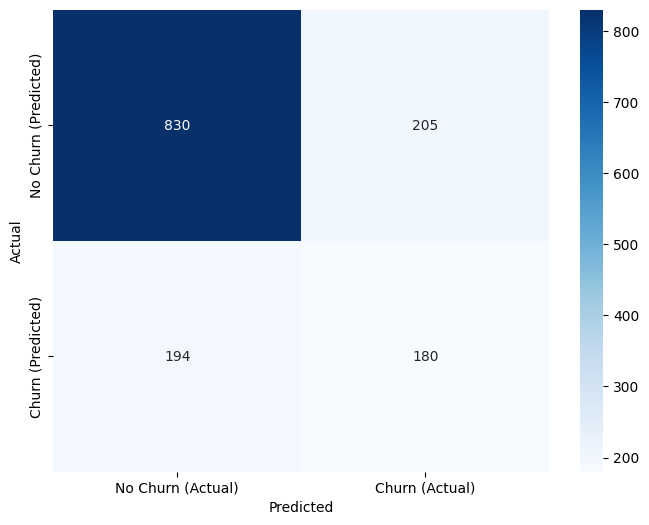

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#Task 10
# Compute metrics on the test set
accuracy = accuracy_score(y_test, DecisionTreeClassifier_test_predictions)
precision = precision_score(y_test, DecisionTreeClassifier_test_predictions)
recall = recall_score(y_test, DecisionTreeClassifier_test_predictions)
f1 = f1_score(y_test, DecisionTreeClassifier_test_predictions)

# Report them in a small table
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})

print("Evaluation Metrics on Test Set")
display(metrics_df)


#Task 11
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, DecisionTreeClassifier_test_predictions)
print("Confusion Matrix:")
#plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn (Actual)', 'Churn (Actual)'], yticklabels=['No Churn (Predicted)', 'Churn (Predicted)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

print(conf_matrix)


**Task 12**

**Given Lab 2's finding about class imbalance, which metric(s) do you trust** **most for this problem, and why?**

**ANS:**

**PART 6**

**13. Compare your baseline tree's accuracy on the training set vs. the test** **set. Is there a large gap? What does that**
**suggest about the model?**

**14. Train several Decision Trees at different max_depth values (e.g. 2, 3, 4,** **5, 6, 8, 10, and unrestricted). Record**
**train accuracy and test accuracy for each in a results table.**

**15. Plot train accuracy and test accuracy against max_depth on the same** **chart. At roughly what depth does the**
**model start to overfit? Explain how the chart shows this.**

In [53]:
#Task 13
accuracy_train = accuracy_score(y_train, DecisionTreeClassifier_train_predictions)
accuracy_test = accuracy_score(y_test, DecisionTreeClassifier_test_predictions)
print("Accuracy on Training Set (default tree):", accuracy_train)
print("Accuracy on Test Set (default tree):", accuracy_test)

#Task 14

results = []

max_depth_values = [2, 3, 4, 5, 6, 8, 10, None]

print("\nTraining Decision Trees with different max_depth values...")
for max_depth in max_depth_values:

    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)


    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)


    accuracy_train = accuracy_score(y_train, train_predictions)
    accuracy_test = accuracy_score(y_test, test_predictions)


    results.append({
        'Max Depth': max_depth if max_depth is not None else 'Unrestricted',
        'Train Accuracy': accuracy_train,
        'Test Accuracy': accuracy_test})


results_df = pd.DataFrame(results)
print("\nDecision Tree Accuracy by Max Depth")
display(results_df)




Accuracy on Training Set (default tree): 0.9980475683351083
Accuracy on Test Set (default tree): 0.716820440028389

Training Decision Trees with different max_depth values...

Decision Tree Accuracy by Max Depth


,Max Depth,Train Accuracy,Test Accuracy
0,2,0.765353,0.750887
1,3,0.791445,0.782115
2,4,0.796592,0.792051
3,5,0.803869,0.798439
4,6,0.810437,0.791341
5,8,0.837238,0.776437
6,10,0.878239,0.756565
7,Unrestricted,0.998048,0.716820


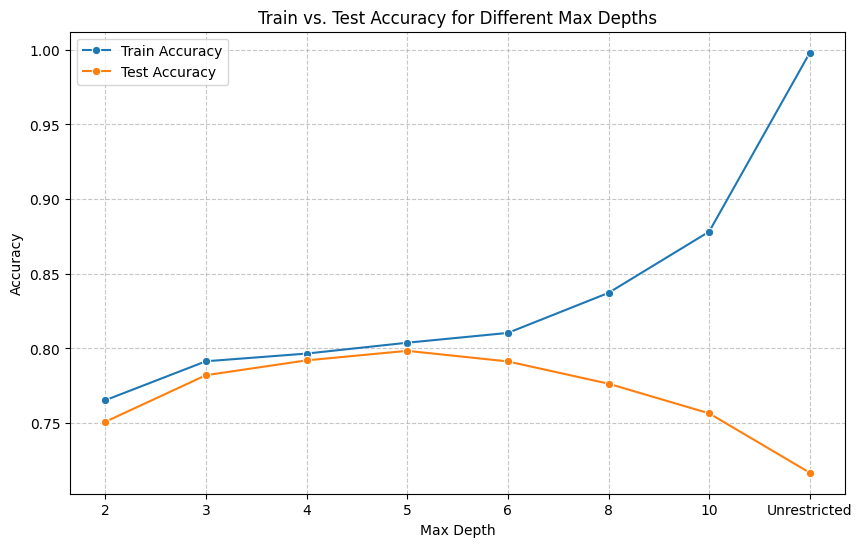

In [51]:
#Task 15

plt.figure(figsize=(10, 6))
sns.lineplot(x=results_df.index, y='Train Accuracy', data=results_df, marker='o', label='Train Accuracy')
sns.lineplot(x=results_df.index, y='Test Accuracy', data=results_df, marker='o', label='Test Accuracy')

plt.title('Train vs. Test Accuracy for Different Max Depths')
plt.xlabel('Max Depth') # Changed label as the actual values are shown in ticks
plt.ylabel('Accuracy')
plt.xticks(ticks=results_df.index, labels=results_df['Max Depth'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


### Overfitting Analysis

Based on the plot, the model starts to show signs of overfitting roughly after a `max_depth` of 5 or 6.

**How the chart shows this:**

*   **Up to `max_depth` of 5-6:** Both train and test accuracies generally increase, or stay relatively close, indicating that the model is learning patterns effectively without memorizing the training data.
*   **Beyond `max_depth` of 5-6:** While the **Train Accuracy** continues to increase (approaching 100% at 'Unrestricted' depth), the **Test Accuracy** either plateaus or begins to decrease. This widening gap between training and test accuracy is a classic sign of overfitting. The model is becoming too complex, learning noise and specific examples from the training data, which hurts its ability to generalize to unseen test data.





16.   Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3
sentences — it should not simply be the depth with the highest training accuracy.

17.    Retrain a Decision Tree at your chosen depth and report   its full evaluation metrics (as in Part 5) for comparison
        against the baseline.

18.   Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its
full evaluation metrics (as in Part 5) for comparison against the baseline.

19.    Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most?


1.   In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the
patterns you saw then?











TASK 16

Q Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3
sentences — it should not simply be the depth with the highest training accuracy.

ANS:

In [57]:
#Task 17
best_max_depth = 5
best_model = DecisionTreeClassifier(max_depth=best_max_depth, random_state=42)
best_model.fit(X_train, y_train)
best_train_predictions = best_model.predict(X_train)
best_test_predictions = best_model.predict(X_test)

best_accuracy_train = accuracy_score(y_train, best_train_predictions)
best_accuracy_test = accuracy_score(y_test, best_test_predictions)

print("Best Model (max_depth =", best_max_depth, ")")
print("Train Accuracy:", best_accuracy_train)
print("Test Accuracy:", best_accuracy_test)


Best Model (max_depth = 5 )
Train Accuracy: 0.80386936457224
Test Accuracy: 0.7984386089425124


In [58]:
#Task 18
Entropy_model = DecisionTreeClassifier(criterion='entropy', max_depth=best_max_depth,random_state=42)
Entropy_model.fit(X_train, y_train)
Entropy_train_predictions = Entropy_model.predict(X_train)
Entropy_test_predictions = Entropy_model.predict(X_test)

Entropy_accuracy_train = accuracy_score(y_train, Entropy_train_predictions)
Entropy_accuracy_test = accuracy_score(y_test, Entropy_test_predictions)

print("Entropy Model (max_depth =", best_max_depth, ")")
print("Train Accuracy:", Entropy_accuracy_train)
print("Test Accuracy:", Entropy_accuracy_test)


Entropy Model (max_depth = 5 )
Train Accuracy: 0.8033368832090877
Test Accuracy: 0.7977288857345636


In [60]:
#Task 19
# Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most?
feature_importances = Entropy_model.feature_importances_
feature_names = X_train.columns
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(feature_importances_df.head(10))

Feature Importances:


,Feature,Importance
37,Contract_Month-to-month,0.534037
0,tenure,0.136579
17,InternetService_Fiber optic,0.123031
1,MonthlyCharges,0.080483
2,TotalCharges,0.031082
44,PaymentMethod_Electronic check,0.024659
39,Contract_Two year,0.021116
28,TechSupport_No,0.015970
19,OnlineSecurity_No,0.013022
22,OnlineBackup_No,0.008207


20. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the
patterns you saw then?

Part 8